In [1]:
import os                   
import cv2                   
import numpy as np            
import pandas as pd         
import matplotlib.pyplot as plt 
import seaborn as sns
from collections import Counter 
from tqdm import tqdm  

In [3]:
# Set consistent plot style
plt.style.use("seaborn-v0_8-whitegrid")

# Define your 5 emotion classes (drop fear and disgust)
EMOTIONS = ['angry', 'happy', 'neutral', 'sad', 'surprise']
TRAIN_DIR = "../data/train/"
TEST_DIR  = "../data/test/"

In [ ]:
print("=== Checking folder structure ===")
for split in ["train", "test"]:
    split_dir = f"../data/{split}/"
    if not os.path.exists(split_dir):
        print(f"[ERROR]MISSING: {split_dir}")
        continue
    for emotion in EMOTIONS:
        path = split_dir + emotion + "/"
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        status = "✓" if count > 0 else "[ERROR]EMPTY"
        print(f"  {status}  {path}  ({count} images)")


=== Checking folder structure ===
  ✓  ../data/train/angry/  (3995 images)
  ✓  ../data/train/happy/  (7215 images)
  ✓  ../data/train/neutral/  (4965 images)
  ✓  ../data/train/sad/  (4830 images)
  ✓  ../data/train/surprise/  (3171 images)
  ✓  ../data/test/angry/  (958 images)
  ✓  ../data/test/happy/  (1774 images)
  ✓  ../data/test/neutral/  (1233 images)
  ✓  ../data/test/sad/  (1247 images)
  ✓  ../data/test/surprise/  (831 images)


In [6]:
# Step 2: Count training images per class
print("\n=== Class Distribution (Train) ===")
train_counts = {}
for emotion in EMOTIONS:
    path  = TRAIN_DIR + emotion + "/"
    count = len([f for f in os.listdir(path)
                if f.endswith(('.jpg','.jpeg','.png'))])
    train_counts[emotion] = count
    print(f"  {emotion:10s}: {count:,} images")

total = sum(train_counts.values())
print(f"\n  Total      : {total:,} images")
print(f"  Max class  : {max(train_counts, key=train_counts.get)}")
print(f"  Min class  : {min(train_counts, key=train_counts.get)}")
print(f"  Imbalance ratio: {max(train_counts.values())/min(train_counts.values()):.1f}x")


=== Class Distribution (Train) ===
  angry     : 3,995 images
  happy     : 7,215 images
  neutral   : 4,965 images
  sad       : 4,830 images
  surprise  : 3,171 images

  Total      : 24,176 images
  Max class  : happy
  Min class  : surprise
  Imbalance ratio: 2.3x


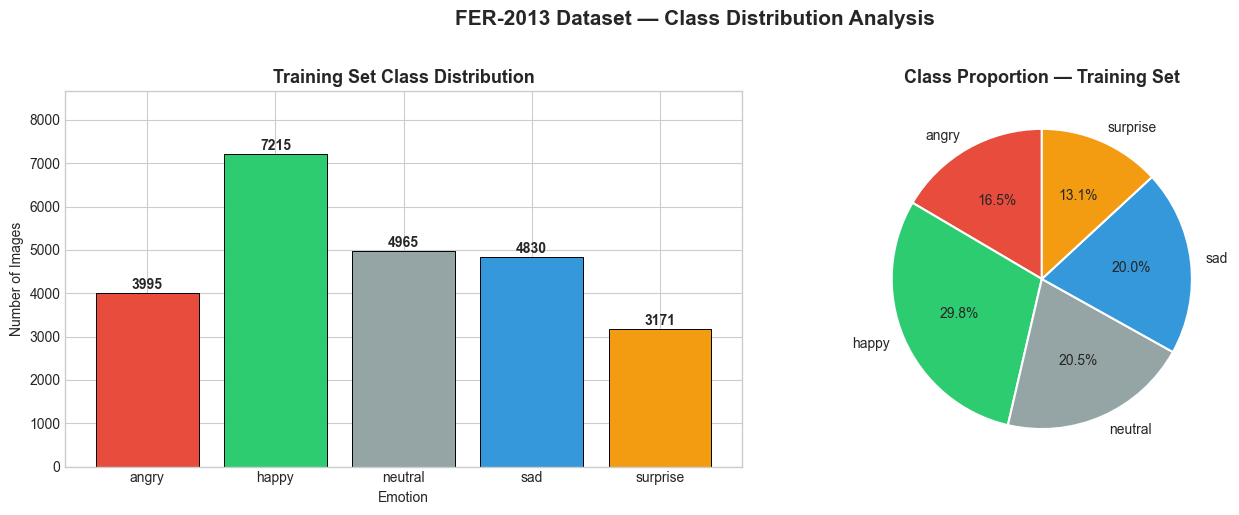

Saved: eda_01_class_distribution.png


In [ ]:
# Step 3: Bar chart of class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: Train set
colors = ['#e74c3c','#2ecc71','#95a5a6','#3498db','#f39c12']
axes[0].bar(train_counts.keys(), train_counts.values(),
            color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title("Training Set Class Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Number of Images")
axes[0].set_ylim(0, max(train_counts.values()) * 1.2)

# Annotate bars with exact counts
for i, (emotion, count) in enumerate(train_counts.items()):
    axes[0].text(i, count + 100, str(count),
                ha='center', fontsize=10, fontweight='bold')

# Right chart: Percentage breakdown (pie chart)
axes[1].pie(train_counts.values(),
            labels=train_counts.keys(),
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title("Class Proportion — Training Set", fontsize=13, fontweight='bold')

plt.suptitle("FER-2013 Dataset — Class Distribution Analysis",
            fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("eda_01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_01_class_distribution.png")

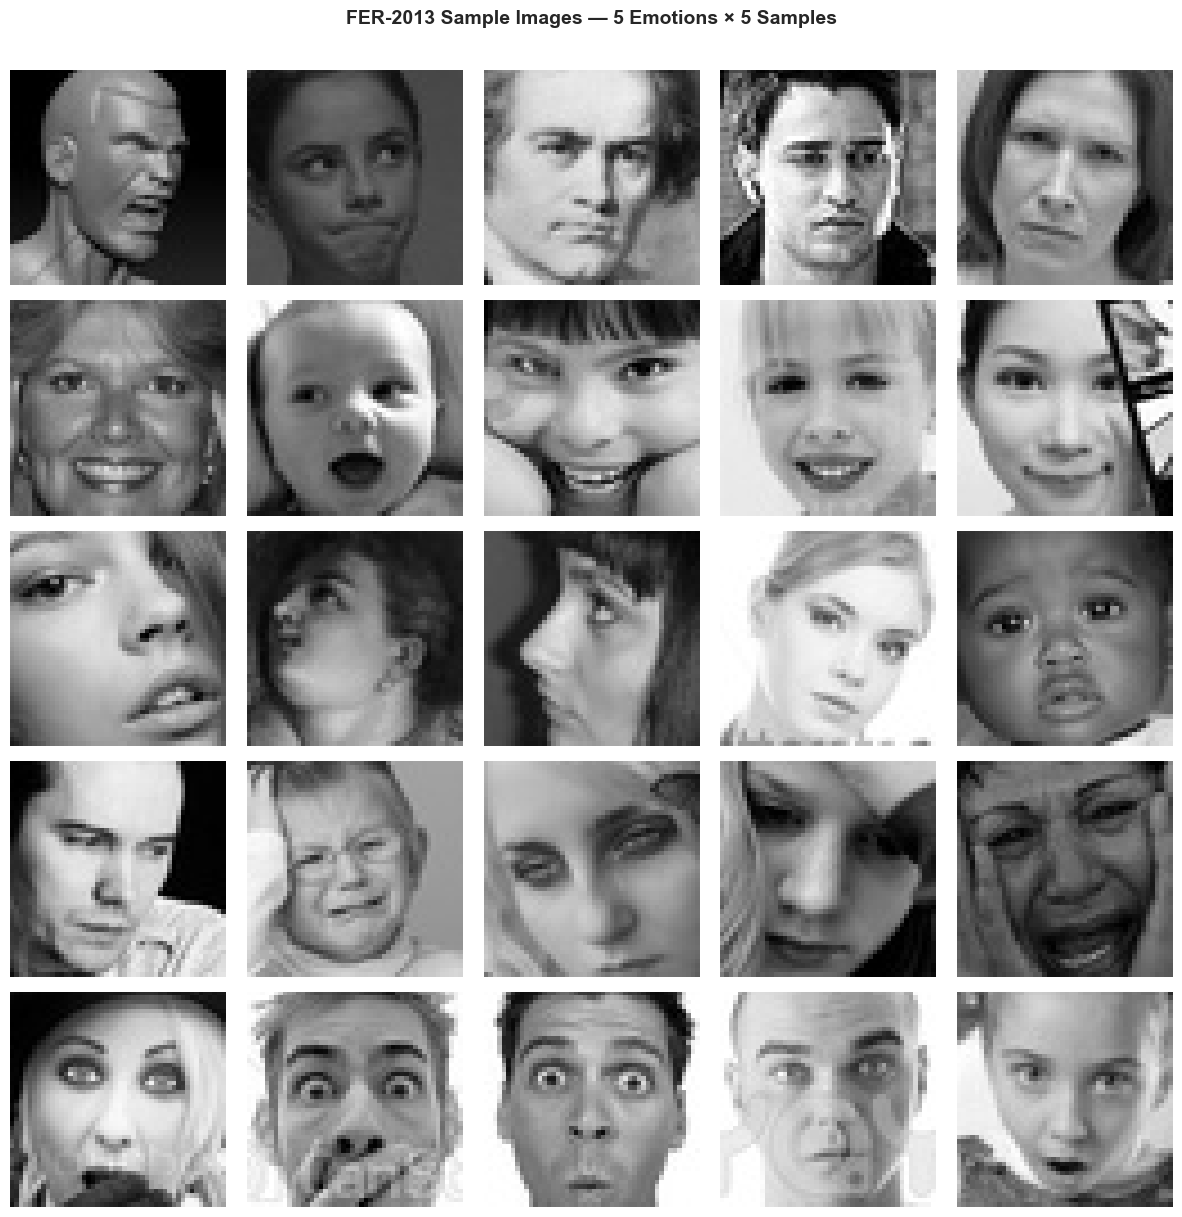

Saved: eda_02_sample_grid.png


In [9]:
# Step 4: 5x5 grid — 5 random samples per emotion
import random
random.seed(42)   # fix seed for reproducibility

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
fig.suptitle("FER-2013 Sample Images — 5 Emotions × 5 Samples",
            fontsize=14, fontweight='bold', y=1.01)

for row, emotion in enumerate(EMOTIONS):
    folder  = TRAIN_DIR + emotion + "/"
    files   = os.listdir(folder)
    samples = random.sample(files, min(5, len(files)))

    for col, fname in enumerate(samples):
        path = folder + fname
        img  = cv2.imread(path)

        if img is None:
            axes[row][col].axis("off")
            continue

        # Convert BGR → RGB for correct matplotlib display
        # OpenCV loads in Blue-Green-Red order
        # matplotlib expects Red-Green-Blue order
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[row][col].imshow(img_rgb, cmap='gray')
        axes[row][col].axis("off")

        # Add emotion label on leftmost column only
        if col == 0:
            axes[row][col].set_ylabel(emotion.upper(),
                                    fontsize=11, fontweight='bold', rotation=90, labelpad=10)
            axes[row][col].yaxis.set_label_position('left')

plt.tight_layout()
plt.savefig("eda_02_sample_grid.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_02_sample_grid.png")

In [10]:
# Step 5: Check image dimensions
print("\n=== Image Dimension Check ===")
dim_counter = Counter()
corrupt     = []

for emotion in EMOTIONS:
    folder = TRAIN_DIR + emotion + "/"
    for fname in os.listdir(folder)[:200]:   # check first 200 per class
        path = folder + fname
        img  = cv2.imread(path)
        if img is None:
            corrupt.append(path)
        else:
            dim_counter[img.shape] += 1

print("Dimension frequencies:")
for shape, count in dim_counter.most_common(5):
    print(f"  {shape}  →  {count} images")

print(f"\nCorrupt/unreadable files: {len(corrupt)}")
if corrupt:
    print("  Examples:", corrupt[:3])


=== Image Dimension Check ===
Dimension frequencies:
  (48, 48, 3)  →  1000 images

Corrupt/unreadable files: 0



=== Computing brightness distributions ===


d:\OneDrive - stevens.edu\26Spri CS513 Knowledge Discovery and Data Mining\Final Project\CS513-Final-Project\notebooks\ipykernel_30388\2420445831.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=EMOTIONS,


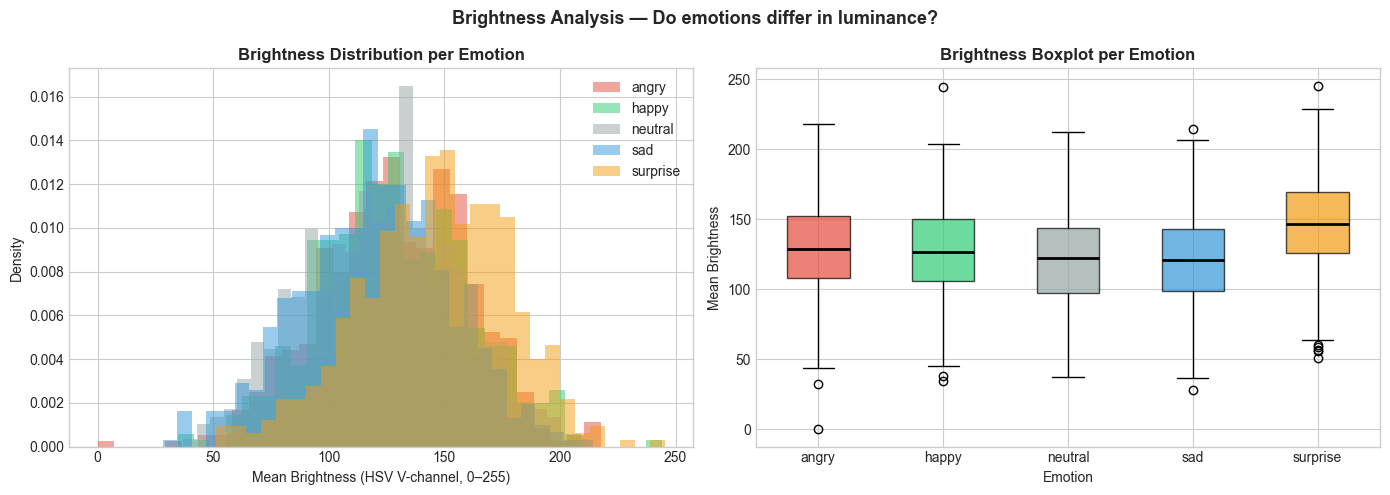

Saved: eda_03_brightness_distribution.png

=== Brightness Summary Stats ===
  angry     : mean=129.0  std=32.4  min=0.0  max=217.8
  happy     : mean=128.2  std=32.0  min=34.7  max=244.2
  neutral   : mean=121.8  std=32.9  min=37.1  max=212.0
  sad       : mean=120.4  std=32.5  min=28.2  max=214.1
  surprise  : mean=145.6  std=32.0  min=51.1  max=245.4


In [ ]:
# Step 6: Brightness distribution per emotion
print("\n=== Computing brightness distributions ===")

brightness_data = {emotion: [] for emotion in EMOTIONS}

for emotion in EMOTIONS:
    folder = TRAIN_DIR + emotion + "/"
    files  = os.listdir(folder)[:500]   # sample 500 per class for speed

    for fname in tqdm(files, desc=emotion, leave=False):
        img = cv2.imread(folder + fname)
        if img is None:
            continue
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        V   = hsv[:,:,2]               # V channel = brightness
        brightness_data[emotion].append(V.mean())   # mean brightness per image

# Plot overlapping histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping density curves
colors = {'angry':'#e74c3c', 'happy':'#2ecc71',
        'neutral':'#95a5a6', 'sad':'#3498db', 'surprise':'#f39c12'}

for emotion in EMOTIONS:
    axes[0].hist(brightness_data[emotion], bins=30,
                alpha=0.5, label=emotion, color=colors[emotion], density=True)

axes[0].set_title("Brightness Distribution per Emotion", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Mean Brightness (HSV V-channel, 0–255)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Right: box plot for cleaner comparison
bp_data  = [brightness_data[e] for e in EMOTIONS]
bp = axes[1].boxplot(bp_data, labels=EMOTIONS,
                    patch_artist=True, medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title("Brightness Boxplot per Emotion", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("Mean Brightness")

plt.suptitle("Brightness Analysis — Do emotions differ in luminance?",
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_03_brightness_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_03_brightness_distribution.png")

# Print summary stats
print("\n=== Brightness Summary Stats ===")
for emotion in EMOTIONS:
    arr = brightness_data[emotion]
    print(f"  {emotion:10s}: mean={np.mean(arr):.1f}  "
        f"std={np.std(arr):.1f}  "
        f"min={np.min(arr):.1f}  "
        f"max={np.max(arr):.1f}")